<a href="https://colab.research.google.com/github/gabifiap/CP_SERS/blob/main/CHECKPOINT_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anna Luiza Carvalhaes RM: 573330

Gabriela Batista RM: 573583

Kethelyn de Oliveira Rocha RM: 574016

Samara Carvalho RM: 573666

IMPORTS

In [ ]:
import pandas as pd

In [ ]:
# Carregar os dados externos do arquivo .csv
dados = pd.read_csv('/content/dataset1.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset1.csv'

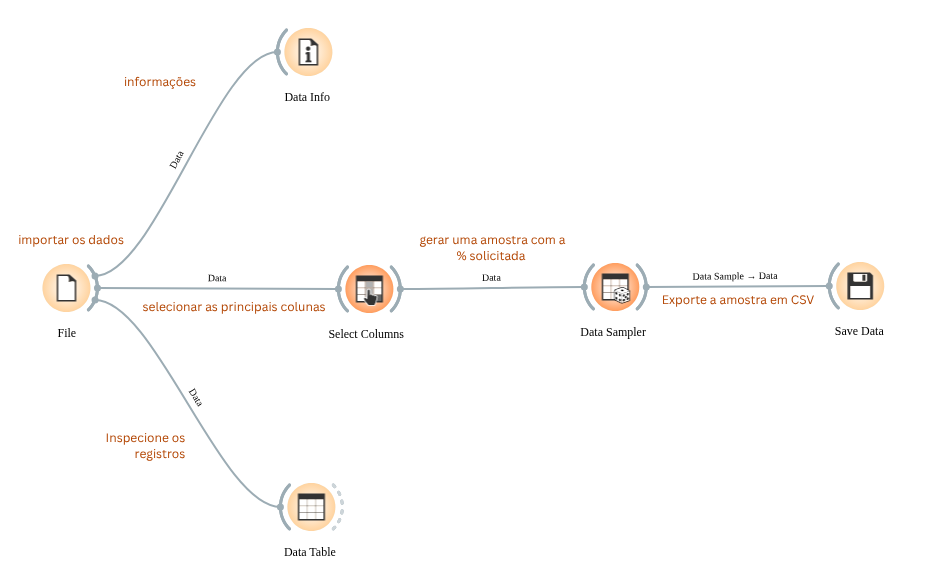

## Dataset 1 — Appliances Energy Prediction (UCI)

Situação: Uma empresa de eficiência energética está analisando o comportamento de uma residência de baixo consumo. A equipe deseja identificar períodos de consumo elevado dos eletrodomésticos e observar quais condições de temperatura e umidade estavam presentes nesses momentos.

1. Carregue a amostra no Pandas e apresente head(), shape, info() e describe().

In [ ]:
# Visualizar os primeiros registros
dados.head()

NameError: name 'dados' is not defined

In [ ]:
# Verificar as dimensões do dataframe
dados.shape

In [ ]:
print(f"O número de registros do dataframe é: {dados.shape[0]}")
print(f"O número de atributos do dataframe é: {dados.shape[1]}")

In [ ]:
# Verificar o formato dos dados
dados.info()

In [ ]:
# Verificar estatísticas descritivas das colunas numéricas
dados.describe()

2. Renomeie Appliances para Consumo_Eletrodomesticos e simplifique o nome de pelo menos três atributos ambientais.

In [ ]:
dados.rename(columns={ 'T1': 'Temp_1',
                              'T2': 'Temp_2',
                              'T3': 'Temp_3',
                              'RH_1': 'Umid_1',
                              'RH_2': 'Umid_2',
                              'RH_3': 'Umid_3',
                              'Appliances': 'Consumo_Eletrodomesticos'
                             }, inplace=True)

# Convertendo a coluna 'Consumo_Eletrodomesticos' para numérica
dados['Consumo_Eletrodomesticos'] = pd.to_numeric(dados['Consumo_Eletrodomesticos'], errors='coerce')

In [ ]:
dados.head()

3. Determine o maior consumo de eletrodomésticos registrado na amostra.

In [ ]:
dados['Consumo_Eletrodomesticos'] = pd.to_numeric(dados['Consumo_Eletrodomesticos'], errors='coerce')
dados['Consumo_Eletrodomesticos'].max()

4. Calcule um limiar correspondente a 70% do valor máximo e crie um DataFrame contendo somente os registros acima desse limite.

In [ ]:
PMAX = dados['Consumo_Eletrodomesticos'].max()

P70 = 0.70 * PMAX

df_alto = dados[dados['Consumo_Eletrodomesticos'] > P70]

In [ ]:
df_alto

5. Conte os registros selecionados e calcule qual percentual da amostra eles representam.

In [ ]:
len(df_alto)
df_alto.shape[0]

In [ ]:
percentual = len(df_alto) / len(dados) * 100
print(f'Percentual: {percentual:.2f}%')

6. Calcule a temperatura média de T1 e crie outro DataFrame contendo simultaneamente consumo acima de 70% do máximo e temperatura acima da média.

In [ ]:
dados['Temp_1'] = pd.to_numeric(dados['Temp_1'], errors='coerce')
media = dados['Temp_1'].mean()
print(f"{media}")

In [ ]:
df_filtrado = dados[
    (dados['Consumo_Eletrodomesticos'] > P70) &
    (dados['Temp_1'] > media)
].copy()

print(df_filtrado)

7. Compare os dois DataFrames e explique o efeito da inclusão da temperatura como segundo critério.

## DATASET 2 - Steel Industry Energy Consumption

1. Carregue a amostra e renomeie Usage_kWh para Consumo_kWh, simplificando também os nomes dos atributos de fator de potência.

In [ ]:
# Carregar os dados externos do arquivo .csv
dataset_2 = pd.read_csv('/content/dataset2.csv')
dataset_2.head()

In [ ]:
dataset_2.rename(columns={
    'Usage_kWh': 'Consumo_kWh'}, inplace=True)
dataset_2.head()

In [ ]:
dataset_2.rename(columns={
    'Lagging_Current_Reactive.Power_kVarh' : 'Energia_reativa_induitiva',
    'Leading_Current_Reactive_Power_kVarh' : 'Energia_reativa_capacitiva',
    'Lagging_Current_Power_Factor' : 'Potencia_induitiva',
    'Leading_Current_Power_Factor' : 'Potencia_capacitiva'
}, inplace=True)

dataset_2.head()


2. Apresente uma inspeção inicial com head(), shape, info() e describe().

In [ ]:
dataset_2.head()

In [ ]:
dataset_2.shape

In [ ]:
dataset_2.info()

In [ ]:
dataset_2.describe()

3. Determine o maior consumo registrado e calcule um limiar de 75% do consumo máximo.

In [ ]:
dataset_2['Consumo_kWh'] = pd.to_numeric(dataset_2['Consumo_kWh'], errors='coerce')
consumo2_max = dataset_2['Consumo_kWh'].max()

consumo2_max

In [ ]:
P75 = 0.75 * consumo2_max

dataset2_filtro = dataset_2[dataset_2['Consumo_kWh'] > P75].copy()
dataset2_filtro

4. Crie um DataFrame contendo os registros acima desse limiar e calcule a quantidade e o percentual de registros.

In [ ]:
total_validos2 = dataset_2['Consumo_kWh'].count()
qtd_registros2 = len(dataset2_filtro)
pct_registros2 = (qtd_registros2 / total_validos2) * 100 if total_validos2 > 0 else 0

print(f"Consumo Máximo: {consumo2_max:.2f} kWh")
print(f"Limiar de 75% (P75): {P75:.2f} kWh")
print(f"Quantidade de registros acima do limiar: {qtd_registros2}")
print(f"Percentual do total de registros válidos: {pct_registros2:.2f}%\n")
print(dataset2_filtro)

5. Verifique quantos registros desse DataFrame pertencem à categoria Maximum Load.

In [ ]:
total = len(dataset2_filtro[dataset2_filtro['Consumo_kWh'] == 'Maximum Load'])
print(total)

print(dataset2_filtro['Consumo_kWh'].value_counts())


6. Escolha um dos atributos de fator de potência, observe seus valores e defina um limite coerente para representar valores mais baixos.

In [ ]:
dataset_2['Potencia_induitiva'] = pd.to_numeric(dataset_2['Potencia_induitiva'], errors='coerce')
PMIN = dataset_2['Potencia_induitiva'].min()

limite_potencia = PMIN / 0.75

df_alto2 = dataset_2[dataset_2['Potencia_induitiva'] <= limite_potencia]

print(f'{PMIN}')

print(f'{df_alto2}')

7. Crie um novo DataFrame contendo simultaneamente consumo elevado e fator de potência abaixo do limite escolhido.

In [ ]:

df_consumo_pf_combinado = dataset_2[
    (dataset_2['Consumo_kWh'] < P75) &
    (dataset_2['Potencia_induitiva'] <= limite_potencia)
].copy()

print("Registros com consumo elevado E fator de potência abaixo do limite:")
print(df_consumo_pf_combinado)

8. Explique por que esse segundo conjunto de registros pode merecer maior atenção da equipe de energia.

O segundo conjunto de dados merece atenção prioritária da equipe de energia porque revela momentos de ineficiência grave na rede.

## DATASET 3 - Power Consumption of Tetouan City

In [ ]:
dataset_3 = pd.read_csv("/content/dataset3.csv")

In [ ]:
dataset_3.head()

1. Renomeie as três variáveis de consumo para Consumo_Zona_1, Consumo_Zona_2 e Consumo_Zona_3.

In [ ]:
dataset_3 = dataset_3.rename(columns ={
    dataset_3.columns[4] : 'Consumo_Zona_1',
    dataset_3.columns[5] : 'Consumo_Zona_2',
    dataset_3.columns[6] : 'Consumo_Zona_3'
})

dataset_3.head()

2. Determine o consumo máximo registrado em cada uma das três zonas.

In [ ]:
dataset_3['Consumo_Zona_1'] = pd.to_numeric(dataset_3['Consumo_Zona_1'], errors='coerce')
dataset_3['Consumo_Zona_2'] = pd.to_numeric(dataset_3['Consumo_Zona_2'], errors='coerce')
dataset_3['Consumo_Zona_3'] = pd.to_numeric(dataset_3['Consumo_Zona_3'], errors='coerce')

maximo_zona1 = dataset_3['Consumo_Zona_1'].max()
maximo_zona2 = dataset_3['Consumo_Zona_2'].max()
maximo_zona3 = dataset_3['Consumo_Zona_3'].max()

print(f'Máximo Consumo Zona 1: {maximo_zona1}')
print(f'Máximo Consumo Zona 2: {maximo_zona2}')
print(f'Máximo Consumo Zona 3: {maximo_zona3}')

3. Identifique qual zona apresenta o maior pico de consumo na amostra.

In [ ]:
# A zona que apresenta maior pico de consumo é a Zona 1, com 51571

4. Para a zona identificada, calcule 70% do valor máximo e crie um DataFrame com os registros acima desse limiar.

In [ ]:
P70_zona1 = 0.70 * maximo_zona1

df_zona1 = dataset_3[dataset_3['Consumo_Zona_1']> P70_zona1]
df_zona1

5. Conte os registros e calcule o percentual que eles representam.

In [ ]:
len(df_zona1)

df_zona1.shape[0]

In [ ]:
percentual = len(df_zona1) / len(dataset_3) * 100

print(f'Percentual: {percentual:.2f}%')

6. Calcule a temperatura média e crie um segundo DataFrame contendo consumo acima do limiar e temperatura acima da média.

In [ ]:
dataset_3['Temperature'] = pd.to_numeric(dataset_3['Temperature'], errors='coerce')
media3 = dataset_3['Temperature'].mean()
media3

In [ ]:
df_resultado = dataset_3[
    (dataset_3['Consumo_Zona_1'] > P70_zona1) &
    (dataset_3['Temperature'] > media3)
].copy()

df_resultado.head()

7. Compare os dois conjuntos e explique o que ocorreu com a quantidade de registros após a inclusão da condição ambiental.

Ouve uma redução númerica no numero de registros, A quantidade de linhas no df_resultado é estritamente menor que os 2.388 registros iniciais. Além disso,grande parte dos picos em sistemas elétricos urbanos é motivada por carga térmica. O novo conjunto refina a amostra para focar nos eventos de pico impulsionados por fatores ambientais.

## DATASET 4 - Solar Power Generation Data (Kaggle)

1. Carregue a amostra e renomeie as principais variáveis para nomes mais claros, como Potencia_CC, Potencia_CA e Geracao_Diaria.

In [ ]:
dataset_4 = pd.read_csv("/content/dataset4.csv")
dataset_4.head()

In [ ]:
dataset_4 = dataset_4.rename(columns = {
    'DC_POWER' : 'Potencia_CC',
    'AC_POWER' : 'Potencia_CA',
    'DAILY_YIELD' : 'Geracao_Diaria',
    'TOTAL_YIELD' : 'Geracao_Total'
})

dataset_4.head()

2. Apresente head(), shape, info() e describe().

In [ ]:
dataset_4.shape

In [ ]:
dataset_4.info()
dataset_4.describe()

In [ ]:
dataset_4.head()

3. Determine a maior potência CA registrada.

In [ ]:
dataset_4['Potencia_CA'] = pd.to_numeric(dataset_4['Potencia_CA'], errors='coerce')
maximo_potencia2 = dataset_4['Potencia_CA'].max()
maximo_potencia2

4. Calcule um limiar correspondente a 70% da potência CA máxima.

In [ ]:
P70_4 = 0.70 * maximo_potencia2
P70_4

5. Crie um DataFrame contendo somente registros acima desse limite e calcule sua quantidade e percentual.

In [ ]:
df_alto4 = dataset_4[dataset_4['Potencia_CA'] > P70_4]
df_alto4

In [ ]:
len(df_alto4)

df_alto4.shape[0]

In [ ]:
percentual4 = len(df_alto4) / len(dataset_4) * 100

print(f'Percentual: {percentual4:.2f}%')

6. Utilize value_counts() em SOURCE_KEY dentro do DataFrame de alta geração.

In [ ]:
frequencia_inversores = df_alto4['SOURCE_KEY'].value_counts()

In [ ]:
frequencia_percentual = df_alto4['SOURCE_KEY'].value_counts(normalize=True) * 100

In [ ]:
print("Frequência absoluta por inversor:")
print(frequencia_inversores)

print("\nFrequência percentual (%):")
print(frequencia_percentual.round(2))

7. Identifique qual inversor aparece com maior frequência nos registros de alta geração e descreva o que esse resultado permite observar, sem concluir desempenho ou falha apenas com esse recorte.

In [ ]:
inversor_mais_frequente = df_alto4['SOURCE_KEY'].value_counts().idxmax()
total_registros = df_alto4['SOURCE_KEY'].value_counts().max()

In [ ]:
print(f"Inversor com maior frequência: {inversor_mais_frequente}")
print(f"Total de registros em alta geração: {total_registros}")

## DATASET 5 - Wind & Solar Energy Production

In [ ]:
df = pd.read_csv('amostra_renovaveis.csv')

1. Renomeie as variáveis principais para Geracao_Solar e Geracao_Eolica.

In [ ]:
df = df.rename(columns={
    'nome_coluna_solar_original': 'Geracao_Solar',
    'nome_coluna_eolica_original': 'Geracao_Eolica'
})

2. Determine o valor máximo registrado para cada fonte.

In [ ]:
max_solar = df['Geracao_Solar'].max()
max_eolica = df['Geracao_Eolica'].max()

print(f"Máximo Solar: {max_solar}")
print(f"Máximo Eólico: {max_eolica}")

3. Calcule separadamente 70% do máximo solar e 70% do máximo eólico.

In [ ]:
limite_solar = 0.70 * max_solar
limite_eolico = 0.70 * max_eolica

print(f"Limite 70% Solar: {limite_solar}")
print(f"Limite 70% Eólico: {limite_eolico}")

4. Crie um DataFrame para registros de alta geração solar e outro para registros de alta geração eólica.

In [ ]:
df_alta_solar = df[df['Geracao_Solar'] >= limite_solar]
df_alta_eolica = df[df['Geracao_Eolica'] >= limite_eolico]

5. Conte os registros de cada DataFrame e calcule seus respectivos percentuais.

In [ ]:
total_registros = len(df)

qtd_alta_solar = len(df_alta_solar)
pct_alta_solar = (qtd_alta_solar / total_registros) * 100

qtd_alta_eolica = len(df_alta_eolica)
pct_alta_eolica = (qtd_alta_eolica / total_registros) * 100

print(f"Alta Geração Solar: {qtd_alta_solar} registros ({pct_alta_solar:.2f}%)")
print(f"Alta Geração Eólica: {qtd_alta_eolica} registros ({pct_alta_eolica:.2f}%)")

6. Compare qual fonte aparece com maior frequência acima de 70% do seu próprio máximo.

In [ ]:
if pct_alta_solar > pct_alta_eolica:
    print(f"A fonte SOLAR aparece com maior frequência acima de 70% do seu máximo ({pct_alta_solar:.2f}% contra {pct_alta_eolica:.2f}% eólica).")
elif pct_alta_eolica > pct_alta_solar:
    print(f"A fonte EÓLICA aparece com maior frequência acima de 70% do seu máximo ({pct_alta_eolica:.2f}% contra {pct_alta_solar:.2f}% solar).")
else:
    print(f"Ambas as fontes apresentaram a mesma frequência de alta geração ({pct_alta_solar:.2f}%).")

## DATASET 6 - Individual Household Electric Power Consumption

1. Carregue a nova amostra e organize os atributos utilizando nomes mais simples.

In [ ]:
dataset_6 = pd.read_csv('/content/dataset6.csv', skiprows=[1, 2])
dataset_6.head()

In [ ]:
dataset_6.rename(columns={
    'Global_active_power': 'Potencia_Ativa',
    'Global_reactive_power': 'Potencia_Reativa',
    'Voltage': 'Tensao',
    'Global_intensity': 'Corrente',
    'Sub_metering_1': 'Submedicao_1',
    'Sub_metering_2': 'Submedicao_2',
    'Sub_metering_3': 'Submedicao_3'
}, inplace=True)

dataset_6.head()

In [ ]:
dataset_6.shape

In [ ]:
dataset_6.info()

In [ ]:
dataset_6.describe()

2. Determine o valor máximo de potência ativa.

In [ ]:
dataset_6['Potencia_Ativa'] = pd.to_numeric(dataset_6['Potencia_Ativa'], errors='coerce')
maximo_potencia_ativa = dataset_6['Potencia_Ativa'].max()
maximo_potencia_ativa

3. Calcule 75% do valor máximo e crie um DataFrame contendo registros acima desse limite.

In [ ]:
P75_6 = 0.75 * maximo_potencia_ativa

df_alto6 = dataset_6[dataset_6['Potencia_Ativa'] > P75_6]
df_alto6

4. Calcule a quantidade e o percentual de registros selecionados.

In [ ]:
qtd_registros6 = len(df_alto6)
percentual6 = qtd_registros6 / len(dataset_6) * 100

print(f'Limiar (75% do máximo): {P75_6:.3f} kW')
print(f'Quantidade de registros acima do limiar: {qtd_registros6}')
print(f'Percentual: {percentual6:.2f}%')

5. Calcule a corrente média da amostra.

In [ ]:
dataset_6['Corrente'] = pd.to_numeric(dataset_6['Corrente'], errors='coerce')
media_corrente = dataset_6['Corrente'].mean()
media_corrente

6. Crie um segundo DataFrame contendo simultaneamente potência ativa acima de 75% do máximo e corrente acima da média.

In [ ]:
df_filtrado6 = dataset_6[
    (dataset_6['Potencia_Ativa'] > P75_6) &
    (dataset_6['Corrente'] > media_corrente)
].copy()

df_filtrado6

7. Compare os dois conjuntos e explique o efeito da inclusão da corrente como segunda condição.

In [ ]:
print(f'Registros só com potência ativa alta: {len(df_alto6)}')
print(f'Registros com potência ativa alta E corrente acima da média: {len(df_filtrado6)}')

NameError: name 'df_alto6' is not defined

As sete variáveis mantidas descrevem o consumo elétrico residencial em escala de minuto.
A Potência Ativa (Potencia_Ativa) varia de 0,078 a 10,65 kW, com média de aproximadamente
1,09 kW — a maior parte dos registros fica concentrada em valores baixos (mediana de 0,604 kW),
indicando uso doméstico típico, com poucos picos de consumo elevado. A Corrente (Global_intensity)
acompanha essa mesma distribuição, já que é diretamente proporcional à potência (P ≈ V × I).
As três submedições (Submedicao_1, 2 e 3) representam circuitos específicos da casa (cozinha,
lavanderia e aquecedor/ar-condicionado) e têm grande variação — muitos valores em zero, indicando
que esses equipamentos ficam desligados na maior parte do tempo.